# ***Import bibliotheques***

In [47]:
#pip install seaborn

In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns


# ***Definir Fonction qui permet de faire la comparaison des algorithmes***
- **Regression Logistique**
- **Naive Bayes**
- **KNN**
- **Decision Tree**

In [49]:

def comparer_modeles(X, y, test_size=0.25, random_state=42, cv=5):
    
    """
    Compare les performances de 4 algorithmes de classification
    
    Parameters:
    -------------------------------------------------------------
    X : array-like, features
    y : array-like, target
    test_size : float, proportion pour le test set
    random_state : int, pour la reproductibilité
    cv : int, nombre de folds pour la validation croisée
    
    Returns:
    ------------------------------------------------------------
    df_scores : DataFrame avec les métriques de performance
    modeles : dict contenant les modèles entraînés
    """
    
    # split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
    
    # Standardisation des features (important pour KNN et Regression Logistique)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Définition des modèles
    modeles = {
        'Regression Logistique': LogisticRegression(random_state=random_state),
        'Naive Bayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=5)
    }
    
    # Stockage des résultats
    results = []
    modeles_entraines = {}
    
    for nom_modele, modele in modeles.items():
        print(f"--> Entraînement de {nom_modele}...")
        
        # Choix des données SI (KNN,Regression Logistique) alors Scaled sinon non) 
        if nom_modele in ['Regression Logistique', 'KNN']:
            X_train_used = X_train_scaled
            X_test_used  = X_test_scaled
        else:
            X_train_used = X_train
            X_test_used  = X_test
        
        # Entraînement du modèle
        modele.fit(X_train_used, y_train)
        
        # Prédictions
        y_pred = modele.predict(X_test_used)
        
        # Calcul des métriques
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Validation croisée
        cv_scores = cross_val_score(modele, X_train_used, y_train, cv=cv, scoring='accuracy')
        cv_mean   = cv_scores.mean()
        cv_std    = cv_scores.std()
        
        # Stockage des résultats
        resultat = {
            'Modèle': nom_modele,
            'Accuracy': round(accuracy, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
            'CV Accuracy Mean': round(cv_mean, 4),
            'CV Accuracy Std': round(cv_std, 4)
        }
        
        results.append(resultat)
        modeles_entraines[nom_modele] = modele
        
        print(f" <#> {nom_modele} terminé - Accuracy: {accuracy:.4f}")
    
    # Création du DataFrame de résultats
    df_scores = pd.DataFrame(results)
    
    return df_scores, modeles_entraines, (X_test, y_test)

# ***Définir fonction qui permet de visualiser la comparaison des modeles***

In [50]:

def visualiser_resultats(df_scores):
    
    """
    Visualise les résultats de comparaison des modèles
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Graphique 1: Accuracy et F1-Score
    metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    x = range(len(df_scores))
    
    for i, metric in enumerate(metrics_to_plot):
        if metric in df_scores.columns:
            axes[0, 0].bar([p + i*0.2 for p in x], df_scores[metric], width=0.2, label=metric)
    
    axes[0, 0].set_title('Comparaison des Métriques Principales')
    axes[0, 0].set_xlabel('Modèles')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_xticks([p + 0.3 for p in x])
    axes[0, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
        
    # Graphique 3: Validation croisée
    axes[1, 0].bar(df_scores['Modèle'], df_scores['CV Accuracy Mean'], 
                   yerr=df_scores['CV Accuracy Std'], capsize=5, alpha=0.7, color='green')
    axes[1, 0].set_title('Accuracy - Validation Croisée (Mean ± Std)')
    axes[1, 0].set_xticklabels(df_scores['Modèle'], rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Heatmap des performances
    metrics_df = df_scores.set_index('Modèle')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', ax=axes[1, 1])
    axes[1, 1].set_title('Heatmap des Performances')
    
    plt.tight_layout()
    plt.show()
    
    # Affichage du tableau des scores
    print("📊 TABLEAU COMPARATIF DES PERFORMANCES")
    print("="*80)
    display(df_scores.style.background_gradient(cmap='Blues', subset=pd.IndexSlice[:, ['Accuracy', 'F1-Score']]))
    
    return df_scores

# ***Péparation des données***

In [51]:
df = pd.read_csv("Trafic_velo.csv")
df.sample(10)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
645315,52.0,24.4,0.0,11.0,31.0,61.0,2,6,1305.0,8
537699,10.0,17.9,0.0,7.2,67.0,14.0,0,5,705.0,4
554234,2.0,13.3,0.0,6.9,96.0,100.0,5,5,345.0,1
235446,3.0,-7.0,0.0,7.9,86.0,100.0,1,3,225.0,1
601183,9.0,15.7,0.0,7.7,38.0,62.0,4,6,690.0,4
687190,0.0,22.5,0.0,12.3,75.0,99.0,0,7,885.0,5
740097,1.0,13.4,0.0,4.7,75.0,6.0,1,7,165.0,1
82121,4.0,-18.8,0.0,10.0,77.0,0.0,2,1,495.0,2
85778,0.0,-12.1,0.0,10.9,76.0,100.0,3,1,435.0,2
428767,0.0,8.2,0.0,9.4,88.0,100.0,5,4,405.0,1


In [52]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


In [73]:
df_v2 = df.copy()
df_v2.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
259818,0.0,-0.1,0.0,5.8,82.0,100.0,0,3,1260.0,8
349210,20.0,4.6,0.0,15.2,69.0,9.0,4,4,555.0,2
321063,14.0,6.2,0.0,13.3,38.0,0.0,3,3,960.0,5
30633,1.0,-11.5,0.0,19.2,75.0,100.0,2,1,1350.0,8
548909,48.0,17.6,0.0,7.9,76.0,96.0,3,5,1005.0,6


##  ***Données Aberantes***

## ***Limiter les valeurs (winsorizing)***

In [ ]:
# Suppression des valeurs extremes

Q1 = df_v2['nb_passages'].quantile(0.25)
Q3 = df_v2['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Limiter les valeurs (winsorizing)
# reduire les données extremes vers la borne superieur
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] < borne_basse, borne_basse, df_v2['nb_passages'])
df_v2['nb_passages'] = np.where(df_v2['nb_passages'] > borne_haute, borne_haute, df_v2['nb_passages'])

df_v2.head(10)

borne_basse :  -16.5
borne_haute :  27.5


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
0,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
1,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
2,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
3,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
5,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
6,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
7,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
8,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1
9,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1


In [75]:
df_v2.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,7.067429,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,3.958754
std,9.597014,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,7.000000
max,27.500000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


## ***Encodage target***

- création de trois groupes qui va nous indiquer s'il s'agit d'un tafique faible, moyen ou fort
- l'interval du nombre de passager  [0,27] sans oublier qu'on a réellement ramener tous les données aberantes vers la valeur 27 cela dit que le groupe qui comporte le nombre 27 est consideré comme fort achalendage
- on peut décider arbitrairement que
  - [ 0 , 9 ]    ----> **1 - faible** achalendage
  - [ 10 , 19 ] ---> **2 - moyen** achalendage 
  - [ 20 , 27 ]  --> **3 - fort** achalendage


0     274911
1      81943
2      53151
3      38547
4      29918
5      24536
6      20379
7      17246
8      14894
9      13072
10     11507
11     10272
12      9399
13      8472
14      7811
15      7491
16      6675
17      6217
18      5951
19      5590
20      5193
21      4835
22      4801
23      4440
24      4348
25      4112
26      3931
27      3770
28     92065
Name: count, dtype: int64


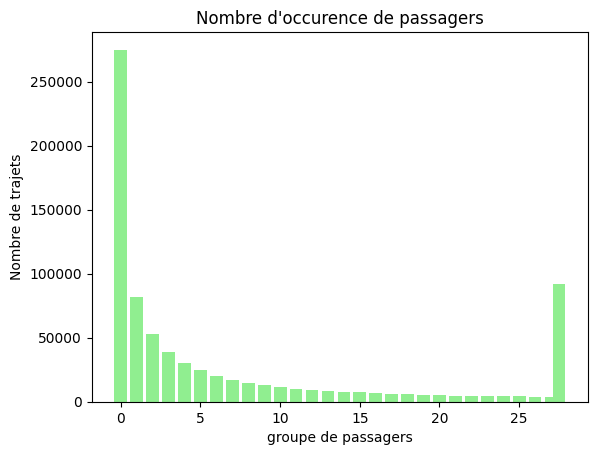

In [78]:
df_gr = df_v2.groupby('nb_passages').size().reset_index(name='count')
print(df_gr['count'].head(30))

plt.bar(df_gr['nb_passages'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de passagers")
plt.xlabel("groupe de passagers")
plt.ylabel("Nombre de trajets")

plt.show()

In [79]:

# Votre code
df_v2['Etat_Circulation'] = pd.cut(
    df_v2['nb_passages'],
    bins=[0, 9, 19, np.inf],
    labels=[1, 2, 3],
    right=True,
    include_lowest=True
)

# Vérification
print(f"Distribution des catégories:")
print(df_v2['Etat_Circulation'].value_counts())

Distribution des catégories:
Etat_Circulation
1    568597
3    127495
2     79385
Name: count, dtype: int64


In [80]:
df_v2.sample(8)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code,Etat_Circulation
724812,27.5,20.6,0.0,19.9,76.0,49.0,3,7,1335.0,8,3
381985,8.0,5.1,0.0,8.2,83.0,81.0,6,4,525.0,2,1
729320,7.0,17.8,0.0,8.8,74.0,0.0,5,7,225.0,1,1
435771,1.0,5.2,0.0,5.7,69.0,0.0,0,4,360.0,1,1
335689,6.0,13.3,0.0,17.7,82.0,100.0,0,3,975.0,5,1
746311,10.0,24.5,0.0,6.9,49.0,17.0,2,7,1170.0,7,2
313735,6.0,3.4,0.0,13.4,70.0,100.0,1,3,945.0,5,1
589637,2.0,16.3,0.0,15.4,89.0,100.0,1,6,330.0,1,1


In [58]:
# drop columns

df_v2 = df_v2.drop(columns=['nb_passages','minutes'])


In [59]:
df_v2.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,periode_code,Etat_Circulation
51712,-5.1,0.0,19.6,78.0,100.0,1,1,3,1
426416,16.3,0.0,8.8,46.0,100.0,4,4,5,3
397503,7.6,0.0,18.3,34.0,11.0,3,4,5,2
302921,4.4,0.0,14.9,82.0,99.0,5,3,6,1
571201,21.6,0.0,11.8,74.0,10.0,3,6,1,1


In [82]:

df_X = df_v2.drop(columns=['Etat_Circulation'])
df_y = df_v2['Etat_Circulation']

print(df_X.shape)
print(df_y.shape)


(775477, 10)
(775477,)


# **Application des algorithmes**

In [61]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.2, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.7724
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.7525
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.7704
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.7847


In [62]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7724,0.6850,0.7724,0.7248,0.7719,0.0008
1,Naive Bayes,0.7525,0.7354,0.7525,0.7290,0.7522,0.0012
2,KNN,0.7704,0.7349,0.7704,0.7491,0.7697,0.0009
3,Decision Tree,0.7847,0.7039,0.7847,0.7421,0.7841,0.0007


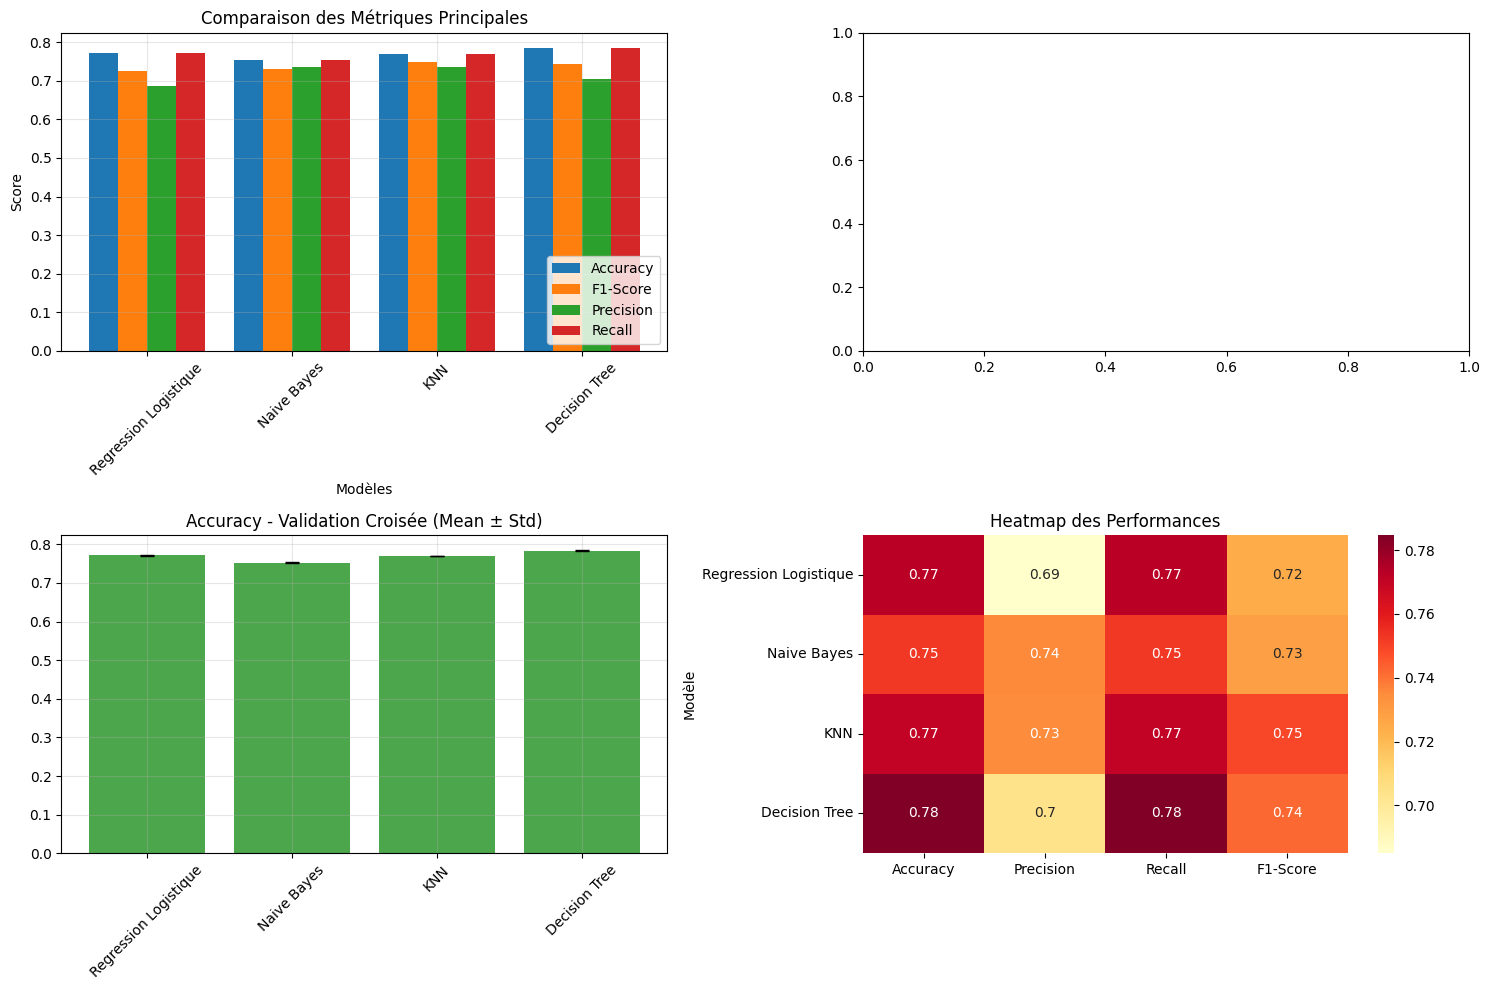

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.772400,0.685000,0.772400,0.724800,0.771900,0.000800
1,Naive Bayes,0.752500,0.735400,0.752500,0.729000,0.752200,0.001200
2,KNN,0.770400,0.734900,0.770400,0.749100,0.769700,0.000900
3,Decision Tree,0.784700,0.703900,0.784700,0.742100,0.784100,0.000700


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.7724,0.6850,0.7724,0.7248,0.7719,0.0008
1,Naive Bayes,0.7525,0.7354,0.7525,0.7290,0.7522,0.0012
2,KNN,0.7704,0.7349,0.7704,0.7491,0.7697,0.0009
3,Decision Tree,0.7847,0.7039,0.7847,0.7421,0.7841,0.0007


In [63]:
visualiser_resultats(df_scores)

# **Application PCA pour la reduction des predicteurs**

## **Definir la courbe du coude**

In [84]:
from sklearn.decomposition import PCA
from bokeh.plotting import figure ,show,output_notebook

output_notebook()

# on créera le model sans specifier le nombre de composants
pca1 = PCA()
X_resultat1 = pca1.fit(df_X).transform(df_X)

variance_explique = pca1.explained_variance_ratio_
print('variance explique : ',variance_explique)

print(pca1.components_)

# id du composant
comp_id = [1,2,3,4,5,6] 

p_pca1 = figure(title='compsantes principales',tools='',x_axis_label='Principal Composant',y_axis_label='variance Explique')
p_pca1.line(comp_id,variance_explique,color='red')
show(p_pca1)

Loading BokehJS ...

variance explique :  [9.87924599e-01 9.22518487e-03 1.58049291e-03 7.82792165e-04
 2.93132311e-04 1.64962452e-04 2.25088547e-05 3.71137274e-06
 1.59459525e-06 1.02107287e-06]
[[ 5.62441352e-03  3.43469596e-03  3.08295327e-05  1.07984091e-03
  -9.52154926e-03  2.27013844e-03  2.22774072e-06  1.02451843e-06
   9.99911458e-01  6.05513669e-03]
 [-2.93474358e-02 -2.37367117e-02  1.66850088e-03  2.35511185e-02
   1.09689013e-01  9.92926701e-01  2.68230309e-03 -8.62979825e-03
  -9.90508361e-04  3.07078088e-04]
 [ 3.80552942e-01  6.56412758e-01 -1.71001934e-03 -3.91305863e-02
  -6.36451743e-01  9.89485449e-02 -5.14696035e-03  8.81104444e-02
  -1.06481918e-02  1.63148117e-03]
 [ 1.32218651e-01  6.38236512e-01  7.71071048e-03 -9.16796766e-02
   7.45405590e-01 -6.02644019e-02  1.74750541e-05  8.61548445e-02
   4.41014080e-03 -2.08963600e-03]
 [ 9.13018985e-01 -3.71009088e-01 -1.41991621e-03 -2.88848595e-02
   1.58191115e-01  9.15575440e-04 -1.25557603e-02 -5.14560627e-02
  -2.27269496e-03 -8.7426

## **essayons de prendre nombre de composant 4 comme la courbe coude le présente**

In [85]:
# on créera le model sans specifier le nombre de composants
pca1 = PCA(n_components=4)
df_PCA = pca1.fit(df_X).transform(df_X)

In [86]:
df_PCA

array([[-712.68763982,   33.43078299,   -6.22315819,    3.05999515],
       [-712.68763982,   33.43078299,   -6.22315819,    3.05999515],
       [-712.68763982,   33.43078299,   -6.22315819,    3.05999515],
       ...,
       [ 712.29702996,  -38.10597968,   -4.48875808,   12.24736484],
       [ 712.40389382,  -38.66358096,    2.74174782,   14.7595192 ],
       [ 712.33640086,  -38.31141173,   -1.82488748,   13.1728954 ]],
      shape=(775477, 4))

## **Application des alogorithme**

In [87]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_PCA, df_y, test_size=0.2, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.8292
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.8154
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.9464
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.8268


In [90]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8292,0.7450,0.8292,0.7848,0.8288,0.0006
1,Naive Bayes,0.8154,0.7322,0.8154,0.7716,0.8146,0.0007
2,KNN,0.9464,0.9445,0.9464,0.9449,0.9420,0.0004
3,Decision Tree,0.8268,0.8044,0.8268,0.7853,0.8254,0.0005


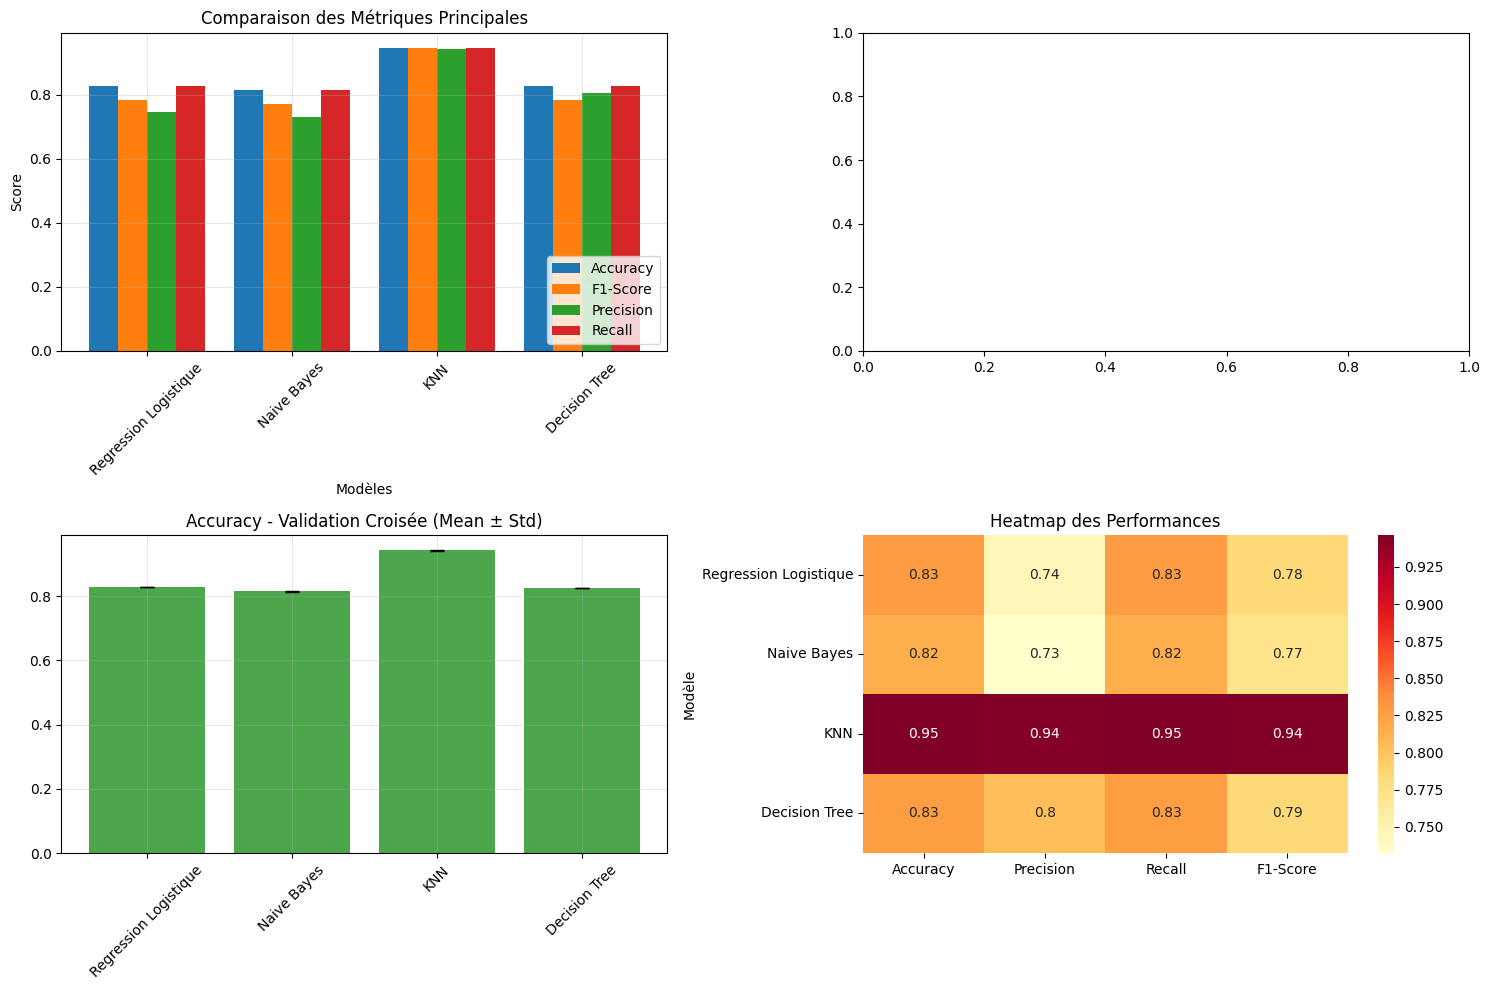

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.829200,0.745000,0.829200,0.784800,0.828800,0.000600
1,Naive Bayes,0.815400,0.732200,0.815400,0.771600,0.814600,0.000700
2,KNN,0.946400,0.944500,0.946400,0.944900,0.942000,0.000400
3,Decision Tree,0.826800,0.804400,0.826800,0.785300,0.825400,0.000500


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.8292,0.7450,0.8292,0.7848,0.8288,0.0006
1,Naive Bayes,0.8154,0.7322,0.8154,0.7716,0.8146,0.0007
2,KNN,0.9464,0.9445,0.9464,0.9449,0.9420,0.0004
3,Decision Tree,0.8268,0.8044,0.8268,0.7853,0.8254,0.0005


In [89]:
visualiser_resultats(df_scores)

# **Analyse des résultat**

- **Analyse de la Distribution Cible**
  - Classe 1 nombre de passager [0-5]   : faible ----- > 73.2% du dataset
  - Classe 2 nombre de passager [6-9]   : moyen  ----- > 16.4% du dataset
  - Classe 3 nombre de passager [10-27] : faible ----- > 10.2% du dataset
- ----------------------------------------------------------------------
  ***La classe 1 est trés majoritaire par rapport au classe 2 et 3 ceci dit qu'au moment de split on pourra fortement avoir des données seulement de la classe 1 pour le jeux de donnée d'entrainement au de tests***  
- **Accuracy est trompeuse :** Un modele naif qui prédit toujours la classe 1 a une accuracy de 73% , notre modele est a 77% ce qui donne que 4% de mieux
- ***Decision Tree le Meilleur Modèle***
  - **Recall 0.7847** : Quand il ya de l'achanladage dans la piste, je la detecte 78% du temps
  - **Precision 0.7039** : quand je prédit achalendage fort, j'ai raison a 70% du temps
    - Ce que signifie : qu'il rate 22% des cas fort achalendé, et se trompe a 30% du temps
- **Regression Logestique : Precision = 0.68.50***
  - Si le modele nous prédit piste achalendé demain dans 31,5% des cas il a tord
- ***KNN : F1-Scroe = 0.7490***
  -  le modele le plus fiable pour le moment, il detecte le mieux l'achanlendage sans les faux positives
  

***INTERPRÉTATION DES MÉTRIQUES***
- ***Cas 1*** : Recall Élevé + Précision Faible
  - → Je detecte presque tout, mais je fais beaucoup de fausses alertes
  - → Utile si : on manque beaucoup un fort achalendage nous coûte très cher
----------------------
- ***Cas 2*** : Précision Élevée + Rappel Faible
  - → Quand on prédit, on a raison, mais on prédit rarement
  - → Utile si : les fausses alertes coûtent très cher
----------------------
- ***Cas 3*** : F1-score Élevé (KNN)
  - → Bon équilibre entre détection et fiabilité
  - → Utile pour : la plupart des applications pratiques
- 

- ***SITUATION RÉELLE*** Avec les chiffres (C1=568k / C2=127k / C3=79k) :
  - ***Le modèles actuels***
    - Prédit l'achalendage faible (73% du temps)
    - Deviennent un experts pour la detection des pistes a faible achalendage
    - Mais paniquent quand ils ya des piste plus achalendé

  - ***Résultat*** : soit que le modele ratent complètement prédiction (mauvais rappel), soit qu'il a fauds positives (mauvaise précision)

- ***On doit absolument rééquilibrer les données !***

# **On va essayer de refaire l'échantillonage**

In [91]:
df.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000,775477.000000
mean,10.429026,5.970146,0.090785,11.060311,71.340174,67.218865,2.996701,3.975160,712.586182,3.958754
std,20.813004,13.603857,0.443573,5.586311,14.981997,39.935158,1.991573,2.015524,415.636310,2.573493
min,0.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,0.000000,-6.000000,0.000000,7.000000,64.000000,26.000000,1.000000,2.000000,360.000000,1.000000
50%,2.000000,6.500000,0.000000,10.400000,73.000000,94.000000,3.000000,4.000000,720.000000,4.000000
75%,11.000000,18.200000,0.000000,14.400000,82.000000,100.000000,5.000000,6.000000,1080.000000,7.000000
max,434.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


***Puisque la classe zéro est majoritaire elle va nous créer du bruit, éliminer catte classe va rendre la distribution uniforme d'ou l'élimination du bruit***

In [101]:
# supression des zéros
df_v3 = df.copy()
df_v3 = df_v3[df_v3['nb_passages'] >0 ]

In [102]:

Q1 = df_v3['nb_passages'].quantile(0.25)
Q3 = df_v3['nb_passages'].quantile(0.75)
IQR = Q3 - Q1

# Définir les limites
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

print('borne_basse : ',borne_basse)
print('borne_haute : ',borne_haute)

# Filtrer les données sans outliers
# suppression des données extremes
df_v3 = df_v3[(df_v3['nb_passages'] >= borne_basse) & (df_v3['nb_passages'] <= borne_haute)]

# Limiter les valeurs (winsorizing)
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] < borne_basse, borne_basse, df_v3['nb_passages'])
#df_v3['nb_passages'] = np.where(df_v3['nb_passages'] > borne_haute, borne_haute, df_v3['nb_passages'])

df_v2.head(10)

borne_basse :  -25.0
borne_haute :  47.0


,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code,Etat_Circulation
0,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
1,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
2,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
3,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
4,2.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
5,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
6,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
7,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
8,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1
9,0.0,0.9,0.0,10.4,88.0,98.0,2,1,0.0,1,1


0     81943
1     53151
2     38547
3     29918
4     24536
5     20379
6     17246
7     14894
8     13072
9     11507
10    10272
11     9399
12     8472
13     7811
14     7491
15     6675
16     6217
17     5951
18     5590
19     5193
20     4835
21     4801
22     4440
23     4348
24     4112
25     3931
26     3770
27     3532
28     3489
29     3255
Name: count, dtype: int64


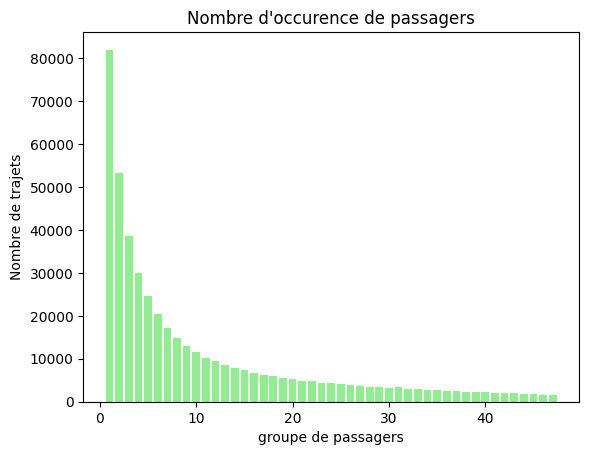

In [103]:
#df_gr = df_v3.groupby('nb_passages')['nb_passages'].count()
#df_gr.head(30)
#plt.bar(df_gr['nb_passages'], df_gr['nb_passages'], color='skyblue')
df_gr = df_v3.groupby('nb_passages').size().reset_index(name='count')
print(df_gr['count'].head(30))

plt.bar(df_gr['nb_passages'], df_gr['count'], color='lightgreen')

plt.title("Nombre d'occurence de passagers")
plt.xlabel("groupe de passagers")
plt.ylabel("Nombre de trajets")

plt.show()

- ***Stratégie :***
  - Éliminer la classe des zéro
  - redimentionner les intervals de tel sorte a obtenir une meilleurs distribution
--------------------------------------

## ***Encodage target***

- Création des groupes d'achanlendage en eliminant la classe zéro :
  - [ 1 , 1 ]    ----> **C1 - tres faible** achalendage
  - [ 2 , 3 ]    ---->  **C2 - assez faible** achalendage 
  - [ 4 , 7 ]    ---->   **C3 - faible** achalendage
  - [ 8 , 15 ]   --->   **C4 - moyen** achalendage
  - [ 16 , 26 ]  -->   **C5 - moins fort** achalendage
  - [ 27 , 28 ]  -->   **C6 - fort** achalendage


In [104]:
df_v3.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000
mean,10.354253,8.602710,0.092082,10.786974,69.949902,66.495906,2.982357,4.317679,768.311210,4.265040
std,11.238264,12.776549,0.456218,5.407684,15.313716,40.000991,1.977895,1.935027,386.663198,2.452399
min,1.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,2.000000,-1.100000,0.000000,6.900000,61.000000,25.000000,1.000000,3.000000,480.000000,2.000000
50%,6.000000,9.900000,0.000000,10.100000,72.000000,93.000000,3.000000,4.000000,780.000000,4.000000
75%,15.000000,19.400000,0.000000,13.900000,81.000000,100.000000,5.000000,6.000000,1095.000000,7.000000
max,47.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


***Creation des classes target d'une facon qu'elle soit uniforme le plus possible***
  - **C1 : [ 1 .. 2 ]**
  - **C2 : [ 3 .. 6 ]**
  - **C3 : [ 7 .. 15 ]**
  - **C4 : [ 16 .. 28 ]** 

In [110]:
df_v3.describe()

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code
count,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000,458198.000000
mean,10.354253,8.602710,0.092082,10.786974,69.949902,66.495906,2.982357,4.317679,768.311210,4.265040
std,11.238264,12.776549,0.456218,5.407684,15.313716,40.000991,1.977895,1.935027,386.663198,2.452399
min,1.000000,-25.400000,0.000000,0.400000,18.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,2.000000,-1.100000,0.000000,6.900000,61.000000,25.000000,1.000000,3.000000,480.000000,2.000000
50%,6.000000,9.900000,0.000000,10.100000,72.000000,93.000000,3.000000,4.000000,780.000000,4.000000
75%,15.000000,19.400000,0.000000,13.900000,81.000000,100.000000,5.000000,6.000000,1095.000000,7.000000
max,47.000000,34.200000,10.000000,36.800000,100.000000,100.000000,6.000000,7.000000,1425.000000,8.000000


In [111]:
df_split = df_v3.copy()
bins = [0,2,6,15, np.inf]
labels = ['C1', 'C2', 'C3','C4']
df_split['Etat_Circulation'] = pd.cut(df_v3['nb_passages'], bins=bins, labels=labels, include_lowest=True)

print(f"Distribution des catégories:")
print(df_split['Etat_Circulation'].value_counts())


Distribution des catégories:
Etat_Circulation
C1    135094
C2    113380
C4    109560
C3    100164
Name: count, dtype: int64


In [112]:
# drop columns

#df_v3 = df_v3.drop(columns=['nb_passages','minutes'])
df_split.sample(5)

,nb_passages,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,minutes,periode_code,Etat_Circulation
412096,21.0,13.5,0.0,11.8,30.0,100.0,0,4,900.0,5,C4
117332,2.0,-8.4,0.0,1.3,82.0,100.0,4,1,735.0,4,C1
90621,7.0,-13.2,0.0,4.5,72.0,0.0,4,1,810.0,5,C3
688051,21.0,17.6,1.0,12.1,90.0,100.0,0,7,1215.0,7,C4
658392,35.0,22.0,0.0,13.5,62.0,100.0,6,6,840.0,5,C4


In [113]:
# suppression ['nb_passages','minutes'] du dataset

df_split = df_split.drop(columns=['nb_passages','minutes'])
df_split.sample(5)

,temp_c,precip_mm,wind_kmh,humidite_pct,cloud_pct,jour_semaine,mois,periode_code,Etat_Circulation
340465,-4.7,0.0,12.0,52.0,5.0,1,4,8,C2
649091,18.5,0.0,3.5,47.0,98.0,3,6,8,C1
301735,-0.3,0.0,9.3,80.0,98.0,5,3,2,C2
323676,-4.7,0.0,13.8,62.0,100.0,4,3,2,C1
401077,11.2,0.0,9.8,47.0,100.0,4,4,5,C4


In [114]:

df_X = df_split.drop(columns=['Etat_Circulation']) # descripteur
df_y = df_split['Etat_Circulation']      # target

print(df_X.shape)
print(df_y.shape)


(458198, 8)
(458198,)


In [115]:
df_scores, modeles_entraines, (X_test, y_test) = comparer_modeles(df_X, df_y, test_size=0.25, random_state=42, cv=5)

--> Entraînement de Regression Logistique...
 <#> Regression Logistique terminé - Accuracy: 0.4361
--> Entraînement de Naive Bayes...
 <#> Naive Bayes terminé - Accuracy: 0.4254
--> Entraînement de KNN...
 <#> KNN terminé - Accuracy: 0.4363
--> Entraînement de Decision Tree...
 <#> Decision Tree terminé - Accuracy: 0.4605


In [109]:
df_scores

,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,0.4361,0.3798,0.4361,0.3587,0.4369,0.0012
1,Naive Bayes,0.4254,0.3710,0.4254,0.3422,0.4257,0.0016
2,KNN,0.4363,0.4252,0.4363,0.4287,0.4353,0.0010
3,Decision Tree,0.4605,0.4033,0.4605,0.3874,0.4603,0.0014


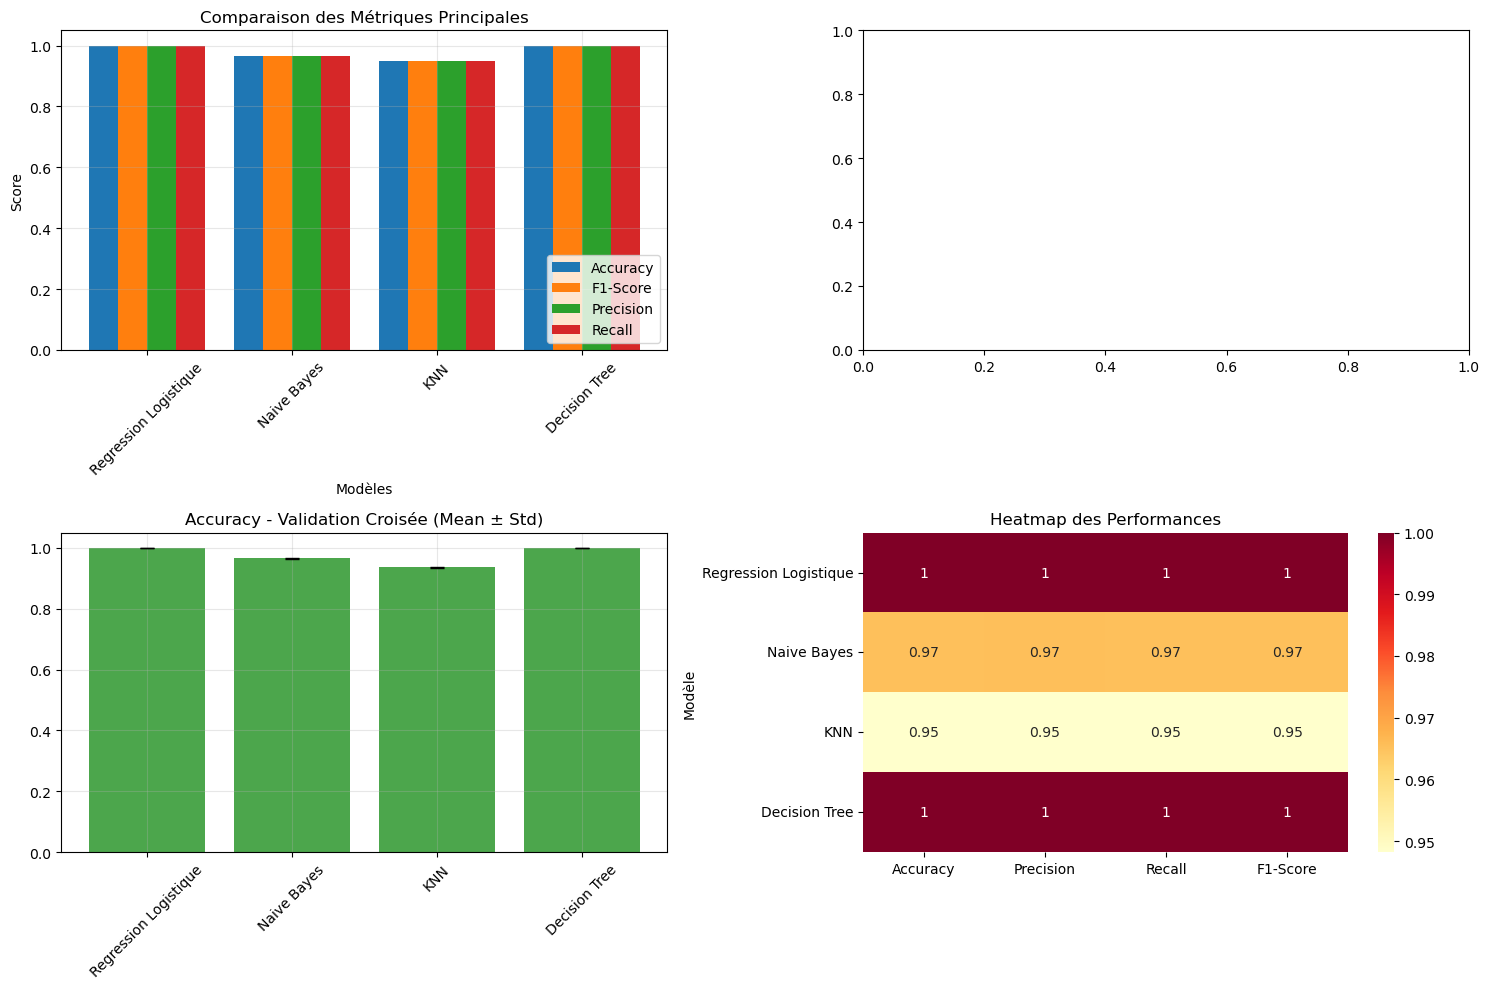

📊 TABLEAU COMPARATIF DES PERFORMANCES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
1,Naive Bayes,0.965300,0.965500,0.965300,0.965300,0.965100,0.000600
2,KNN,0.948200,0.948300,0.948200,0.948200,0.936200,0.001000
3,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Accuracy Mean,CV Accuracy Std
0,Regression Logistique,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
1,Naive Bayes,0.9653,0.9655,0.9653,0.9653,0.9651,0.0006
2,KNN,0.9482,0.9483,0.9482,0.9482,0.9362,0.0010
3,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000


In [114]:
import seaborn as sns
visualiser_resultats(df_scores)